## CS82SL013639.16+000818.38

This notebook intend to analyse our first system. We are going to use the Python module called AutoLens [AutoLens](https://pyautolens.readthedocs.io/en/latest/index.html) and [Lenstronomy](https://lenstronomy.readthedocs.io/).

Attention: Configuration folder and output path results are needed. Otherwise, this notebook are going to have a full run. 

In [1]:
# basics imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u

# autolens package
import autolens as al
import autofit as af
import autolens.plot as aplt

# lenstronomy package
from lenstronomy.Util import util
from lenstronomy.Data.psf import PSF
from lenstronomy.Data.imaging_data import ImageData
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.Plots import chain_plot
from lenstronomy.Plots.model_plot import ModelPlot
from lenstronomy.ImSim.image_model import ImageModel
from lenstronomy.LensModel.lens_model import LensModel
from lenstronomy.LightModel.light_model import LightModel
from lenstronomy.Util import param_util

%matplotlib inline

2022-01-27 14:54:57,324 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autofit/config


2022-01-27 14:54:57,482 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autogalaxy/config
2022-01-27 14:54:57,611 - autoconf.conf - WARNING - Pushing new config with path /home/joao/.local/lib/python3.8/site-packages/autolens/config


In [2]:
def rotate_matrix(m):
    return [[m[j][i] for j in range(len(m))] for i in range(len(m[0])-1,-1,-1)]

In [3]:
def gen_image_noise_pointsource(header, noise_map, positions, grid_scale):
    """
    This def function generates a set of image list and a noise map one
    """
    w = WCS(header)
    noise_map_pointsource = []
    new_positions = []
    noise_map_func = noise_map.reshape(150,150)
    noise_map_func = rotate_matrix(noise_map_func.T)

    for i in range(0, len(positions)):
        sky_coord_object=SkyCoord(ra=positions[i][0]*u.degree, dec=positions[i][1]*u.degree, frame='icrs')
        pos = w.world_to_pixel(sky_coord_object)
        noise_map_pointsource.append(noise_map_func[round(float(pos[0]))][round(float(pos[1]))])
        print(round(float(pos[0])), round(float(pos[1])))
        new_positions.append([float(pos[1]-75.5)*grid_scale, float(pos[0]-75.5)*grid_scale])
            
    return new_positions, noise_map_pointsource

In [4]:
def rel_deg_to_arcsec(img_x, img_y, origin):
    img_x = img_x - origin[0]
    img_y = img_y - origin[1]
    for i in range(0, len(img_x)):
        img_x[i] = (img_x[i]*u.deg).to(u.arcsec).value
        img_y[i] = (img_y[i]*u.deg).to(u.arcsec).value
        
    return img_x, img_y

## AutoLens Analysis

In [5]:
# output paths
images_path = './images/'

# image and psf file path
image_file = './imgblock.fits'
original_image_file = './013639.fits'
psf_file = './psf2.fits'

# point-source positions determined by Anna
ps_positions_x_ds9 = [24.163159, 24.162377, 24.162791, 24.163895]
ps_positions_y_ds9 = [0.13943114, 0.13793125, 0.13761556, 0.1381123]
# fluxes for ds9
fluxes_ds9 = np.array([0.522189, 1.00239, 1.21172, 0.979199])
noise_map_ds9 = np.array([0.0683054, 0.0693873, 0.0701082, 0.0682936])

ps_positions_x_bary = [24.163108, 24.162375, 24.162887, 24.163871]
ps_positions_y_bary = [0.13940833, 0.13794167, 0.13762222, 0.13808333]
# fluxes for bary
fluxes_bary = np.array([0.738677, 1.00239, 1.14413, 1.09726])
noise_map_bary = np.array([0.0680063, 0.0693873, 0.0699194, 0.0682448])

ps_positions_x_peak = [24.16319, 24.162364, 24.162829, 24.163914]
ps_positions_y_peak = [0.139424, 0.137977, 0.137615, 0.138132]
# fluxes for peak
fluxes_peak = np.array([0.65321, 1.12264, 1.25332, 0.979199])
noise_map_peak = np.array([0.0680697, 0.0694676, 0.0704707, 0.0682936])

# reference position, here, the center of a fits image
reference_position = [24.163281, 0.13847326]

# conversion parameter between pixel and arcsec
grid_scale = 27.9/150.

# redshifts
lens_redshift = 0.344
source_redshift = 1.

* Full bright distribution analysis

### Loading our images

In [6]:
# residual image after galaxy subtraction
residual_image = al.Array2D.from_fits(image_file,
                                      pixel_scales=grid_scale,
                                      hdu=3)
# psf image
psf = al.Kernel2D.from_fits(psf_file,
                            hdu=0,
                            pixel_scales=grid_scale)
# reescaling psf to have an odd dimension Autolens requirement
psf=psf.rescaled_with_odd_dimensions_from_rescale_factor(rescale_factor=1)
# in order to avoid uneccessary convolution time we reescaled psf to have a new shape
psf = al.preprocess.array_with_new_shape(array=psf, new_shape=(17, 17))
# generating our noise-map image with a fix variation
# rms variation given by a background subtraction
var = 11387.1
# loading original image
original_image = al.Array2D.from_fits(image_file,
                                      pixel_scales=grid_scale,
                                      hdu=2)
# image header
image_header = fits.open(original_image_file)[0].header
# noise map generation
noise_map = np.sqrt(original_image*image_header['TEXPTIME']+var)/image_header['TEXPTIME'] # ADU/s
# imaging object
imaging = al.Imaging(image=residual_image, psf=psf, noise_map=noise_map)
# applying a circular mask
mask = al.Mask2D.circular(shape_native=imaging.shape_native, pixel_scales=imaging.pixel_scales, radius=12)
imaging = imaging.apply_mask(mask=mask)

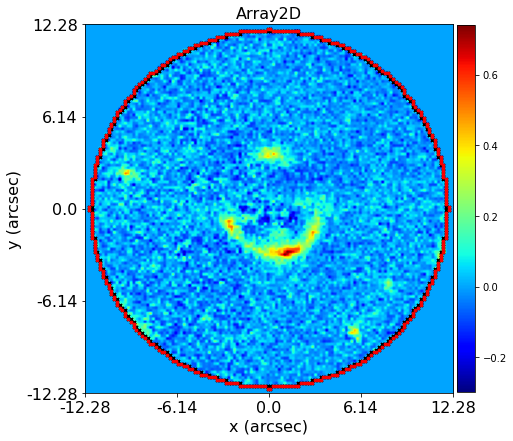

In [7]:
# cell to realize a cross-check analysis, if everything is ok them proceed
visuals_2d = aplt.Visuals2D()
array_plotter = aplt.Array2DPlotter(array=imaging.image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

In [8]:
# autolens benchmark model
# source galaxy model
source_galaxy_model = af.Model(al.Galaxy,
                               redshift=source_redshift,
                               disk=al.lp.EllExponential)
# bulge
bulge = af.Model(al.lp.EllDevVaucouleurs)
# lens galaxy model
lens_galaxy_model = af.Model(al.Galaxy,
                             redshift=lens_redshift,
                             bulge=bulge,
                             mass=al.mp.EllIsothermal)
# combining our previous components
autolens_model = af.Collection(galaxies=af.Collection(lens=lens_galaxy_model, source=source_galaxy_model))

In [9]:
# autolens fit full bright distribution
search = af.DynestyStatic(path_prefix = './',
                          unique_tag = '013639_run1',
                          nlive = 30,
                          number_of_cores = 5) # be carefull here! verify your core numbers
analysis = al.AnalysisImaging(dataset=imaging)
result_al_fbd = search.fit(model=autolens_model, analysis=analysis) # fbd = full bright distribution

2022-01-27 14:54:59,970 - autofit.non_linear.abstract_search - INFO - Creating search
2022-01-27 14:54:59,973 - root - INFO - Starting search
2022-01-27 14:55:00,080 - root - INFO - Already completed, skipping non-linear search.
2022-01-27 14:55:00,108 - root - INFO - Removing zip file


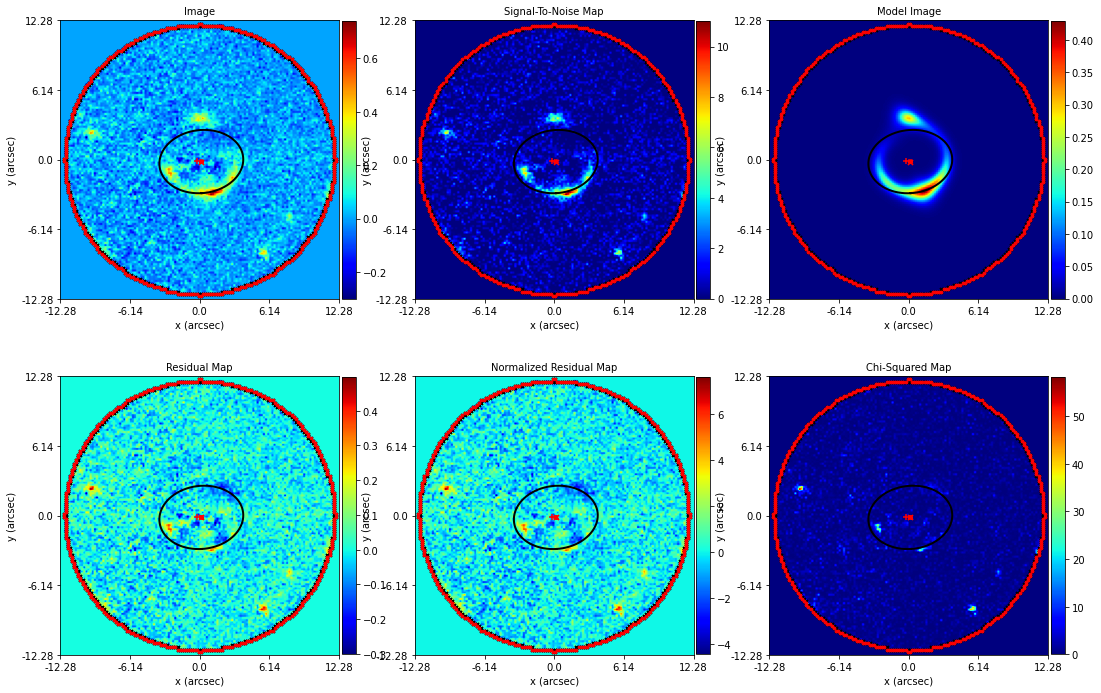

In [10]:
fit_imaging_plotter = aplt.FitImagingPlotter(fit=result_al_fbd.max_log_likelihood_fit)
fit_imaging_plotter.subplot_fit_imaging()

In [11]:
result_al_fbd.max_log_likelihood_fit.model_image.output_to_fits(images_path+"autolens_013639_run1.fits", overwrite=True)

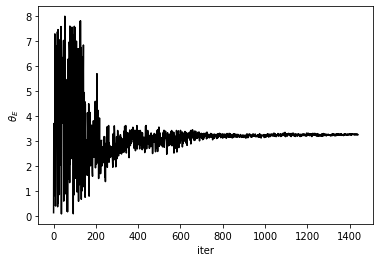

In [12]:
# checking convergency
plt.plot(result_al_fbd.samples.results['samples'].T[-1], 'k')
plt.xlabel('iter')
plt.ylabel('$θ_E$');

In [13]:
burnin = 400

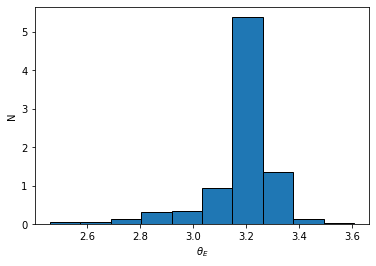

In [14]:
plt.hist(result_al_fbd.samples.results['samples'].T[-1][burnin:], ec='k', density=True)
plt.xlabel('$θ_E$')
plt.ylabel('N');

In [15]:
fbd_autolens_chain = pd.DataFrame(result_al_fbd.samples.results['samples'].T, np.array(result_al_fbd.samples.names).flatten(), ).T
fbd_autolens_chain.head()

,galaxies_source_disk_centre_0,galaxies_source_disk_centre_1,galaxies_source_disk_elliptical_comps_0,galaxies_source_disk_elliptical_comps_1,galaxies_source_disk_intensity,galaxies_source_disk_effective_radius,galaxies_lens_bulge_centre_0,galaxies_lens_bulge_centre_1,galaxies_lens_bulge_elliptical_comps_0,galaxies_lens_bulge_elliptical_comps_1,galaxies_lens_bulge_intensity,galaxies_lens_bulge_effective_radius,galaxies_lens_mass_centre_0,galaxies_lens_mass_centre_1,galaxies_lens_mass_elliptical_comps_0,galaxies_lens_mass_elliptical_comps_1,galaxies_lens_mass_einstein_radius
0,0.033408,0.107298,-0.346623,0.103078,0.002577,9.088510,0.335313,0.492140,-0.050909,-0.720980,325961.040086,23.406904,-0.134591,0.095806,-0.189180,-0.063965,0.123160
1,-0.285932,0.561002,0.104924,-0.429723,231.282837,4.253246,0.163313,-0.084947,0.102159,-0.014785,695103.481363,9.946331,0.004933,0.039574,0.038658,-0.171761,3.688113
2,-0.387394,0.108164,0.486725,-0.165678,34993.732719,10.993894,-0.071646,-0.336309,-0.008742,0.844526,237484.752572,24.598149,-0.112341,-0.068920,-0.043316,0.167532,0.807667
3,-0.146651,-0.015855,-0.272354,0.181724,647619.092744,19.459073,-0.227688,-0.338286,-0.022548,-0.450549,59842.813089,22.877860,-0.168970,0.065715,-0.108724,0.289729,0.814658
4,-0.181163,-0.134277,-0.606567,-0.034860,698543.270227,7.743388,-0.608567,-0.757760,0.121448,0.157402,9.841393,14.420141,-0.021259,-0.273532,0.285351,0.028136,3.339253


In [16]:
fbd_autolens_chain.to_csv('./output_dataframes/autolens_013639_fbd.csv')

* DS9 point source analysis using AutoLens 

In [17]:
# ds9 AutoLens positions and corresponding noise map values
pos_ds9_al, noise_map_ds9_al = gen_image_noise_pointsource(image_header, noise_map, [list(a) for a in zip(ps_positions_x_ds9, ps_positions_y_ds9)], grid_scale)
# building our positions catalog
image_pos_cat = al.PointDataset(name='point_0',
                                positions = al.Grid2DIrregular(pos_ds9_al),
                                positions_noise_map = al.ValuesIrregular(noise_map_ds9_al)
                        )
# position dictionary
point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

2022-01-27 14:55:06,363 - astropy - WARNING - FITSFixedWarning: RADECSYS= 'ICRS ' / Astrometric system 
the RADECSYS keyword is deprecated, use RADESYSa.
2022-01-27 14:55:06,372 - astropy - WARNING - FITSFixedWarning: 'datfix' made the change 'Set MJD-END to 55507.000000 from DATE-END'.
75 94
90 65
82 59
60 69


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


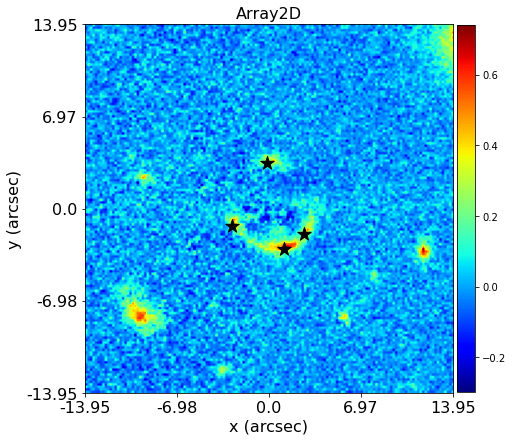

In [18]:
# visualizing our positions. If its ok, them proceed
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)
array_plotter = aplt.Array2DPlotter(array=residual_image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

In [19]:
# point-source model
# lens model
lens = af.Model(al.Galaxy, redshift=lens_redshift, mass=al.mp.EllIsothermal)
# source model
source = af.Model(al.Galaxy, redshift=source_redshift, point_0=al.ps.Point)
# model
autolens_model = af.Collection(galaxies=af.Collection(lens=lens, source=source))

In [20]:
# commom 2d grid, it uses the image's grid
grid = al.Grid2D.uniform(
    shape_native=residual_image.shape_native, pixel_scales=residual_image.pixel_scales
)
# looks like an initial guess for our image positions
positions_solver = al.PositionsSolver(grid=grid, pixel_scale_precision=0.05)

In [21]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix = './',
    name = '013639_ds9',
    nlive = 30,
    number_of_cores = 5,
)

2022-01-27 14:55:07,005 - autofit.non_linear.abstract_search - INFO - Creating search


In [22]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result_al_ds9 = search.fit(model=autolens_model, analysis=analysis)

2022-01-27 14:55:07,015 - 013639_ds9 - INFO - Starting search
2022-01-27 14:55:07,051 - 013639_ds9 - INFO - Already completed, skipping non-linear search.
2022-01-27 14:55:07,059 - 013639_ds9 - INFO - Removing zip file


In [23]:
# exporting our results
ds9_autolens_chain = pd.DataFrame(result_al_ds9.samples.results['samples'].T, np.array(result_al_ds9.samples.names).flatten(), ).T
ds9_autolens_chain.head()

,galaxies_lens_mass_centre_0,galaxies_lens_mass_centre_1,galaxies_lens_mass_elliptical_comps_0,galaxies_lens_mass_elliptical_comps_1,galaxies_lens_mass_einstein_radius,galaxies_source_point_0_centre_0,galaxies_source_point_0_centre_1
0,0.074691,-0.100906,0.119948,0.262577,7.828743,0.188010,-0.401467
1,0.000122,0.106540,0.359143,0.193789,7.726432,0.113568,0.266634
2,0.163454,-0.007513,0.423596,-0.100922,7.547138,-0.334639,-0.162231
3,-0.022377,-0.002102,-0.191582,0.095187,5.741890,0.250709,0.640900
4,-0.185778,-0.117534,0.924278,0.430558,2.981374,0.062020,0.221579


In [24]:
ds9_autolens_chain.to_csv('./output_dataframes/autolens_013639_ds9.csv')

* Barycenter point source analysis using AutoLens 

In [25]:
# barycenter AutoLens positions and corresponding noise map values
pos_bary_al, noise_map_bary_al = gen_image_noise_pointsource(image_header, noise_map, [list(a) for a in zip(ps_positions_x_bary, ps_positions_y_bary)], grid_scale)
# building our positions catalog
image_pos_cat = al.PointDataset(name='point_0',
                                positions = al.Grid2DIrregular(pos_bary_al),
                                positions_noise_map = al.ValuesIrregular(noise_map_bary_al)
                        )
# position dictionary
point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

2022-01-27 14:55:07,217 - astropy - WARNING - FITSFixedWarning: RADECSYS= 'ICRS ' / Astrometric system 
the RADECSYS keyword is deprecated, use RADESYSa.
2022-01-27 14:55:07,225 - astropy - WARNING - FITSFixedWarning: 'datfix' made the change 'Set MJD-END to 55507.000000 from DATE-END'.
76 94
90 65
80 59
61 68


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


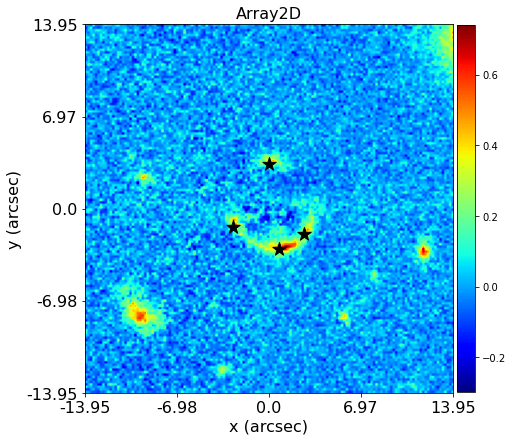

In [26]:
# visualizing our positions. If its ok, them proceed
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)
array_plotter = aplt.Array2DPlotter(array=residual_image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

In [27]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix = './',
    name = '013639_bary',
    nlive = 30,
    number_of_cores = 5,
)

2022-01-27 14:55:07,578 - autofit.non_linear.abstract_search - INFO - Creating search


In [28]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result_al_bary = search.fit(model=autolens_model, analysis=analysis)

2022-01-27 14:55:07,590 - 013639_bary - INFO - Starting search
2022-01-27 14:55:07,623 - 013639_bary - INFO - Already completed, skipping non-linear search.
2022-01-27 14:55:07,634 - 013639_bary - INFO - Removing zip file


In [29]:
# exporting our results
bary_autolens_chain = pd.DataFrame(result_al_bary.samples.results['samples'].T, np.array(result_al_bary.samples.names).flatten(), ).T
bary_autolens_chain.head()

,galaxies_lens_mass_centre_0,galaxies_lens_mass_centre_1,galaxies_lens_mass_elliptical_comps_0,galaxies_lens_mass_elliptical_comps_1,galaxies_lens_mass_einstein_radius,galaxies_source_point_0_centre_0,galaxies_source_point_0_centre_1
0,0.028032,-0.148219,-0.021234,-0.015098,7.096727,-0.283979,-0.010355
1,0.028760,0.018727,-0.419948,0.002010,7.935815,-0.620250,0.014370
2,0.078408,-0.052332,0.061071,0.319466,6.664709,-0.404838,-0.399580
3,0.056481,0.075765,0.242696,0.490353,7.678276,-0.153528,0.058804
4,-0.158403,0.162964,0.295597,-0.146143,6.335154,-0.153587,0.169234


In [30]:
bary_autolens_chain.to_csv('./output_dataframes/autolens_013639_bary.csv')

* Peak point source analysis using AutoLens 

In [31]:
# peak AutoLens positions and corresponding noise map values
pos_peak_al, noise_map_peak_al = gen_image_noise_pointsource(image_header, noise_map, [list(a) for a in zip(ps_positions_x_peak, ps_positions_y_peak)], grid_scale)
# building our positions catalog
image_pos_cat = al.PointDataset(name='point_0',
                                positions = al.Grid2DIrregular(pos_peak_al),
                                positions_noise_map = al.ValuesIrregular(noise_map_peak_al)
                        )
# position dictionary
point_dict = al.PointDict(point_dataset_list=[image_pos_cat])

2022-01-27 14:55:07,800 - astropy - WARNING - FITSFixedWarning: RADECSYS= 'ICRS ' / Astrometric system 
the RADECSYS keyword is deprecated, use RADESYSa.
2022-01-27 14:55:07,810 - astropy - WARNING - FITSFixedWarning: 'datfix' made the change 'Set MJD-END to 55507.000000 from DATE-END'.
74 94
90 66
81 59
60 69


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


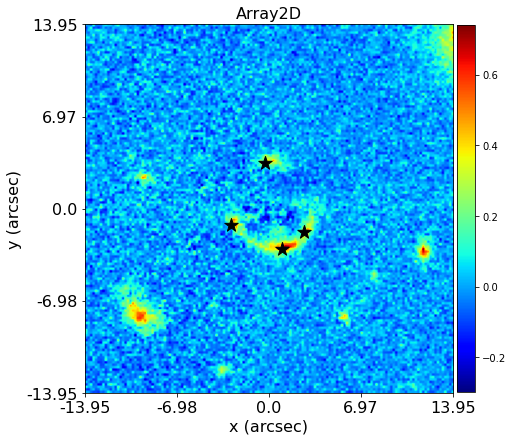

In [32]:
# visualizing our positions. If its ok, them proceed
visuals_2d = aplt.Visuals2D(positions=point_dict.positions_list)
array_plotter = aplt.Array2DPlotter(array=residual_image, visuals_2d=visuals_2d)
array_plotter.figure_2d()

In [33]:
# model path and cores for fit
search = af.DynestyStatic(
    path_prefix = './',
    name = '013639_peak',
    nlive=30,
    number_of_cores=5,
)

2022-01-27 14:55:08,134 - autofit.non_linear.abstract_search - INFO - Creating search


In [34]:
# fit our model
analysis = al.AnalysisPoint(point_dict=point_dict, solver=positions_solver)
result_al_peak = search.fit(model=autolens_model, analysis=analysis)

2022-01-27 14:55:08,142 - 013639_peak - INFO - Starting search
2022-01-27 14:55:08,160 - 013639_peak - INFO - Already completed, skipping non-linear search.
2022-01-27 14:55:08,167 - 013639_peak - INFO - Removing zip file


In [35]:
# exporting our results
peak_autolens_chain = pd.DataFrame(result_al_peak.samples.results['samples'].T, np.array(result_al_peak.samples.names).flatten(), ).T
peak_autolens_chain.head()

,galaxies_lens_mass_centre_0,galaxies_lens_mass_centre_1,galaxies_lens_mass_elliptical_comps_0,galaxies_lens_mass_elliptical_comps_1,galaxies_lens_mass_einstein_radius,galaxies_source_point_0_centre_0,galaxies_source_point_0_centre_1
0,0.036964,0.003403,-0.049617,0.341320,7.684086,-0.237040,0.336004
1,0.009014,0.122451,0.091876,0.024742,5.904812,-0.406379,-0.096483
2,0.090758,0.140892,0.456940,-0.136165,7.641005,0.167204,-0.169151
3,0.082519,-0.041466,-0.227502,-0.008899,6.349629,-0.190343,0.026239
4,0.106788,0.026870,-0.366833,-0.282727,0.306493,0.087832,0.695561


In [36]:
peak_autolens_chain.to_csv('./output_dataframes/autolens_013639_peak.csv')

## Lenstronomy Analysis

* Full bright distribution

In [37]:
# general configurations
_, _, ra_at_xy_0, dec_at_xy_0, _, _, Mpix2coord, _ = util.make_grid_with_coordtransform(numPix=150, deltapix=grid_scale, center_ra=0, center_dec=0, subgrid_res=1, inverse=False)
# models for lens, source and point-source
lens_model = ['SIE']
source_model = ['SERSIC_ELLIPSE']
point_source_model = ['LENSED_POSITION']

lens_model_class = LensModel(lens_model_list=lens_model)
source_model_class = LightModel(light_model_list=source_model)
# rms background in ADUs
background_rms = 0.0686448

In [38]:
# setting image and psf. Note that they both need to be reeshaped, this is a lenstronomy requirement. In order to save memory, I am going to rewrite our previous quantities.
psf = np.array(psf).reshape(17, 17) # 17 in reference to our previous reesize
residual_image_lenstronomy = np.array(residual_image).reshape(150, 150) # 150x150 image
# here, we need to rotate our matrix, reshape brings this trouble to us
residual_image_lenstronomy = np.array(rotate_matrix(residual_image_lenstronomy.T))
# note that in lenstronomy we do not need a noise map, just a rms background

In [39]:
# kwargs for a full bright distribution fit

# data input parameters
kwargs_data = {'background_rms': background_rms,  # rms of background noise
               'exposure_time': image_header["TEXPTIME"],  # exposure time (or a map per pixel)
               'ra_at_xy_0': ra_at_xy_0,  # RA at (0,0) pixel
               'dec_at_xy_0': dec_at_xy_0,  # DEC at (0,0) pixel 
               'transform_pix2angle': Mpix2coord,  # matrix to translate shift in pixel in shift in relative RA/DEC (2x2 matrix). Make sure it's units are arcseconds or the angular units you want to model.
               'image_data': np.zeros((150, 150))  # 2d data vector, here initialized with zeros as place holders that get's overwritten once a simulated image with noise is created.
              }

# psf kwargs
kwargs_psf = {'psf_type': 'PIXEL', 'pixel_size': grid_scale, 'kernel_point_source': psf}
psf_class = PSF(**kwargs_psf)
# some fit parameters
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}
# seting image kwargs
data_class = ImageData(**kwargs_data)
data_class.update_data(residual_image_lenstronomy)
kwargs_data['image_data'] = residual_image_lenstronomy

In [40]:
# setting our priors
######## Lens ########
fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

# initial guess, sigma, upper and lower parameters
fixed_lens.append({})
kwargs_lens_init.append({'theta_E': 3.3, 'e1': 0.07, 'e2': 0.03, # Einstein radius, eccentricity and lens positions
                         'center_x': 0.3, 'center_y': 0.6})
kwargs_lens_sigma.append({'theta_E': .05, 'e1': 0.05, 'e2': 0.05, # 1-sigma values
                         'center_x': 0.05, 'center_y': 0.05}) 
# upper and lower bounds
kwargs_lower_lens.append({'theta_E': 3.1, 'e1': -0.1, 'e2': -0.1, 'center_x': -10, 'center_y': -10})
kwargs_upper_lens.append({'theta_E': 4., 'e1': 0.1, 'e2': 0.1, 'center_x': 10, 'center_y': 10})

# intitial guess for the lens positions
fixed_lens.append({'ra_0': 0, 'dec_0': 0})
# gamma parameters, initial guess, sigma, upper and lower bounds
kwargs_lens_init.append({'gamma1': 0., 'gamma2': 0.0})
kwargs_lens_sigma.append({'gamma1': 0.1, 'gamma2': 0.1})
kwargs_lower_lens.append({'gamma1': -0.2, 'gamma2': -0.2})
kwargs_upper_lens.append({'gamma1': 0.2, 'gamma2': 0.2})

# creating an object to have all this attributes
lens_params = [kwargs_lens_init, kwargs_lens_sigma, fixed_lens, kwargs_lower_lens, kwargs_upper_lens]

######## Lens ########
fixed_source = []
kwargs_source_init = []
kwargs_source_sigma = []
kwargs_lower_source = []
kwargs_upper_source = []

# initial guess, sigma, upper and lower parameters
fixed_source.append({})
kwargs_source_init.append({'R_sersic': 0.2, 'n_sersic': 1, 'e1': 0, 'e2': 0, 'center_x': 0., 'center_y': 0}) # R sersic parameter, n sersic index, eccentricities and x and y centers
kwargs_source_sigma.append({'n_sersic': 0.5, 'R_sersic': 0.1, 'e1': 0.05, 'e2': 0.05, 'center_x': 0.2, 'center_y': 0.2}) # 1-sigma values
# upper and lower bounds
kwargs_lower_source.append({'e1': -1., 'e2': -1., 'R_sersic': 0.001, 'n_sersic': .5, 'center_x': -10, 'center_y': -10})
kwargs_upper_source.append({'e1': 1., 'e2': 1., 'R_sersic': 10, 'n_sersic': 5., 'center_x': 10, 'center_y': 10})

# creating an object to have all this attributes
source_params = [kwargs_source_init, kwargs_source_sigma, fixed_source, kwargs_lower_source, kwargs_upper_source]

######## Lens light (or bulge) ########  
fixed_lens_light = []
kwargs_lens_light_init = []
kwargs_lens_light_sigma = []
kwargs_lower_lens_light = []
kwargs_upper_lens_light = []

fixed_lens_light.append({})
kwargs_lens_light_init.append({'amp':1., 'R_sersic': 0.5, 'n_sersic': 2, 'e1': 0., 'e2': 0, 'center_x': 0., 'center_y': 0}) # flux amplitude (not really important), R sersic parameter, n sersic index xparameter, eccentricities and x and y centers
kwargs_lens_light_sigma.append({'amp':1., 'n_sersic': 1, 'R_sersic': 0.3, 'e1': 0.5, 'e2': 0.5, 'center_x': 0.1, 'center_y': 0.1}) # 1-sigma values
# upper and lower bounds
kwargs_lower_lens_light.append({'amp':1., 'e1': -1., 'e2': -0.5, 'R_sersic': 0.001, 'n_sersic': .5, 'center_x': -10, 'center_y': -10})
kwargs_upper_lens_light.append({'amp':1., 'e1': 1., 'e2': 0.5, 'R_sersic': 10, 'n_sersic': 5., 'center_x': 10, 'center_y': 10})

# creating an object to have all this attributes
lens_light_params = [kwargs_lens_light_init, kwargs_lens_light_sigma, fixed_lens_light, kwargs_lower_lens_light, kwargs_upper_lens_light]

# setting lens and source parameters (Einstein raidius, eccentricities, R sersic, etc)
kwargs_params = {'lens_model': lens_params,
                'source_model': source_params}

# Likelihood kwargs
kwargs_likelihood = {'source_marg': False}
kwargs_model = {'lens_model_list': lens_model, 'source_light_model_list': source_model}
# here, we have 1 single band to fit
multi_band_list = [[kwargs_data, kwargs_psf, kwargs_numerics]]
# if you have multiple  bands to be modeled simultaneously, you can append them to the mutli_band_list
kwargs_data_joint = {'multi_band_list': multi_band_list, 
                     'multi_band_type': 'multi-linear'  # 'multi-linear': every imaging band has independent solutions of the surface brightness, 'joint-linear': there is one joint solution of the linear coefficients demanded across the bands.
                    }
# we dont have a contraint
kwargs_constraints = {}

/tmp/ipykernel_817/3146599180.py:3: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("gray").copy()
  cmap.set_bad(color='k', alpha=1.)
/tmp/ipykernel_817/3146599180.py:4: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("gray").copy()
  cmap.set_under('k')


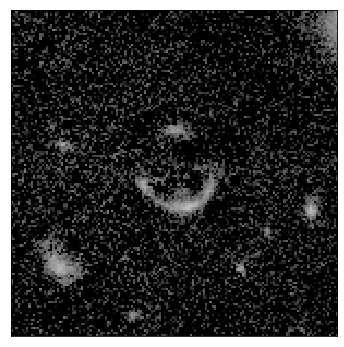

In [41]:
cmap_string = 'gray'
cmap = plt.get_cmap(cmap_string)
cmap.set_bad(color='k', alpha=1.)
cmap.set_under('k')

v_min = -4
v_max = 1

f, axes = plt.subplots(1, 1, figsize=(6, 6), sharex=False, sharey=False)

ax = axes
im = ax.matshow(np.log(residual_image_lenstronomy), origin='lower', vmin=v_min, vmax=v_max, cmap=cmap, extent=[0, 1, 0, 1])
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.autoscale(False)

plt.show()

In [42]:
# running an mcmc algorithm
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params)
fitting_kwargs_list = [['MCMC', {'n_burn': 200, 'n_run': 600, 'walkerRatio': 10, 'sigma_scale': .1}]
        ]
fbd_lenstronomy = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_fbd_result = fitting_seq.best_fit()

2022-01-27 13:17:24,955 - lenstronomy.Sampling.Pool.pool - INFO - Running with SerialPool


100%|█████████████████████████████████████████████████████████████████████████████████| 800/800 [10:32<00:00,  1.26it/s]

Computing the MCMC...
Number of walkers =  110
Burn-in iterations:  200
Sampling iterations (in current run): 800
633.2932591438293 time taken for MCMC sampling


-1.1998595121735083 reduced X^2 of all evaluated imaging data combined.
reduced chi^2 of data  0 =  1.199859512173508


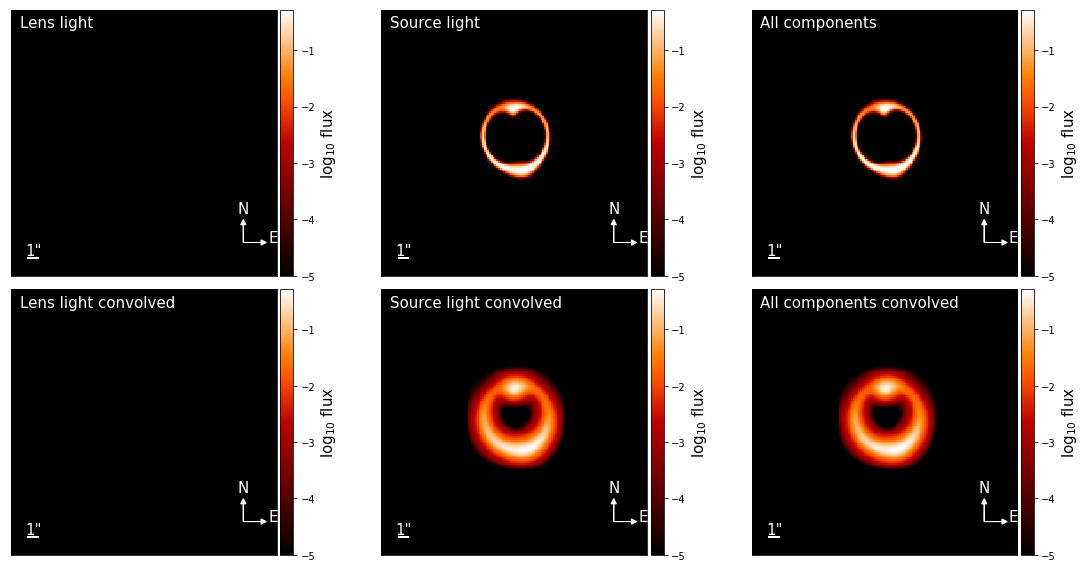

In [43]:
# check it out our results!
modelPlot = ModelPlot(multi_band_list, kwargs_model, kwargs_fbd_result, arrow_size=0.02, cmap_string='gist_heat')
modelPlot.plot_separate(band_index=0);

In [44]:
# building a pandas dataframe and a fits file
results_path = './output_lenstronomy/'
fbd_lenstronomy_chain = pd.DataFrame(fbd_lenstronomy[0][1].T, fbd_lenstronomy[0][2])
fbd_lenstronomy_chain = fbd_lenstronomy_chain.T

# exporting our image result
imageModel = ImageModel(data_class, psf_class, lens_model_class,
                        source_model_class,
                        kwargs_numerics=kwargs_numerics)
image = imageModel.image(kwargs_lens=kwargs_fbd_result['kwargs_lens'],
                             kwargs_source=kwargs_fbd_result['kwargs_source'])
hdu = fits.PrimaryHDU(data=image)

In [45]:
fbd_lenstronomy_chain

,theta_E_lens0,e1_lens0,e2_lens0,center_x_lens0,center_y_lens0,R_sersic_source_light0,n_sersic_source_light0,e1_source_light0,e2_source_light0,center_x_source_light0,center_y_source_light0
0,3.285115,-0.062958,0.007446,0.142331,0.735086,0.162552,0.555818,-0.344948,-0.003124,0.186983,0.333352
1,3.306014,-0.063053,0.012563,0.161174,0.798343,0.191125,0.615650,-0.263965,0.016508,0.203149,0.363276
2,3.292221,-0.062293,0.009980,0.134242,0.776385,0.186746,0.613982,-0.273828,-0.027913,0.183547,0.334121
3,3.284118,-0.069831,0.008716,0.116168,0.797030,0.172201,0.664455,-0.356393,0.014392,0.167233,0.336882
4,3.312565,-0.057063,0.008190,0.184909,0.775932,0.206030,1.007206,-0.244232,-0.026344,0.230441,0.339377
...,...,...,...,...,...,...,...,...,...,...,...
65995,3.349072,-0.050928,-0.002773,0.213201,0.659280,0.112374,0.504968,-0.573270,-0.265532,0.249849,0.398131
65996,3.343873,-0.049340,-0.000736,0.217676,0.651061,0.108069,0.512602,-0.534478,-0.205238,0.256941,0.397732
65997,3.324075,-0.055793,0.003140,0.165138,0.689451,0.136356,0.503486,-0.500020,-0.180485,0.215216,0.357263
65998,3.299431,-0.059071,-0.013470,0.210003,0.564433,0.084408,0.591909,-0.525101,-0.347551,0.224823,0.415711


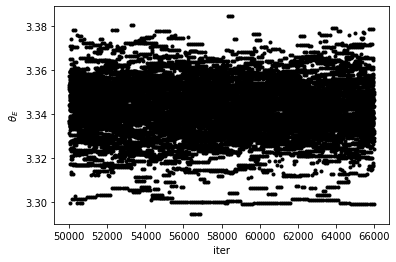

In [46]:
plt.plot(fbd_lenstronomy_chain['theta_E_lens0'][50000:], 'k.')
plt.xlabel('iter')
plt.ylabel('$θ_E$');

In [47]:
burnin = 40000

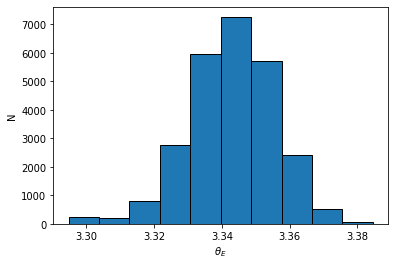

In [48]:
# checking convergency
plt.hist(fbd_lenstronomy_chain['theta_E_lens0'][burnin:], ec='k')
plt.xlabel('$θ_E$')
plt.ylabel('N');

In [76]:
# exporting chain results
fbd_lenstronomy_chain.to_csv('./output_dataframes/lenstronomy_013639_fbd.csv')
hdu.writeto(images_path+'/lenstronomy_013639_run1.fits')

* DS9 point source analysis using Lenstronomy 

In [42]:
#_, noise_map_ds9_al = gen_image_noise_pointsource(image_header, original_image, [list(a) for a in zip(ps_positions_x_ds9, ps_positions_y_ds9)], grid_scale)

In [43]:
# converting positions
img_x, img_y = rel_deg_to_arcsec(np.array(ps_positions_x_ds9), np.array(ps_positions_y_ds9), reference_position)
# ratios
flux_ratios = fluxes_ds9[1:] / fluxes_ds9[0]
# a little approximation here, error propagation over the ratio
flux_ratio_errors = [noise_map_ds9[0]/fluxes_ds9[1], noise_map_ds9[0]/fluxes_ds9[2], noise_map_ds9[0]/fluxes_ds9[3]]

#flux_ratio_errors = np.sqrt(flux_erros_ds9[1:] / flux_erros_ds9[0])

flux_ratio_likelihood = True  # bool, modeling the flux ratios of the images

# error on positions
astrometry_sigma = 0.005

In [44]:
# kwargs for a point-source fit

# we chose to model the image positions in the lensed plane (we know where they appear)
fixed_ps = [{}]  # neither image fixed
kwargs_ps_init = [{'ra_image': img_x, 'dec_image': img_y}] # the initial guess for the appearing image positions is: at the image position.
kwargs_ps_sigma = [{'ra_image': 0.01 * np.ones(len(img_x)), 'dec_image': 0.01 * np.ones(len(img_x))}]
kwargs_lower_ps = [{'ra_image': -10 * np.ones(len(img_x)), 'dec_image': -10 * np.ones(len(img_x))}]
kwargs_upper_ps = [{'ra_image': 10* np.ones(len(img_x)), 'dec_image': 10 * np.ones(len(img_x))}]

# combine all parameter options for lenstronomy
ps_params = [kwargs_ps_init, kwargs_ps_sigma, fixed_ps, kwargs_lower_ps, kwargs_upper_ps]

# kwargs over flux and source type
kwargs_flux_compute = {'source_type': 'INF',  # you can either chose 'INF' which is a infinetesimal source sice, 'GAUSSIAN' or 'TORUS'
                       'window_size': grid_scale, # window size to compute the finite source magnification (only when 'GAUSSIAN' or 'TORUS' are chosen.)
                       'grid_number': 150}

kwargs_data_joint = {'flux_ratios': flux_ratios, 
                     'flux_ratio_errors': flux_ratio_errors,
                    'ra_image_list': [img_x], 'dec_image_list': [img_y]}

# our model choices
kwargs_model = {'lens_model_list': lens_model, 
                'point_source_model_list': point_source_model
                 }
# neither important constraint to use
kwargs_constraints = {'num_point_source_list': [len(img_x)]              
                     }
# Likelihood kwargs
kwargs_likelihood = {'image_position_uncertainty': astrometry_sigma,  # astrometric uncertainty of image positions
                     'image_position_likelihood': True, # evaluate point source likelihood given the measured image positions
                     'flux_ratio_likelihood': flux_ratio_likelihood,  # enables the flux ratio likelihood 
                     'kwargs_flux_compute': kwargs_flux_compute,  # source_type='INF' will lead to point source
                     'check_bounds': True,  # check parameter bounds and punish them
                    }

kwargs_params = {'lens_model': lens_params,
                'point_source_model': ps_params}

In [45]:
#and now we run the MCMC
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params)

fitting_kwargs_list = [
    ['MCMC', {'n_burn': 400, 'n_run': 600, 'walkerRatio': 10,'sigma_scale': 0.1}]
]
ds9_lenstronomy = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_ds9_result = fitting_seq.best_fit()

2022-01-27 14:55:10,618 - lenstronomy.Sampling.Pool.pool - INFO - Running with SerialPool


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:29<00:00, 33.64it/s]

Computing the MCMC...
Number of walkers =  130
Burn-in iterations:  400
Sampling iterations (in current run): 1000
29.799229860305786 time taken for MCMC sampling


In [46]:
kwargs_ds9_result

{'kwargs_lens': [{'theta_E': 3.6472414449289237,
   'e1': -0.07915531397815115,
   'e2': -0.05150700352365265,
   'center_x': 0.586129698160847,
   'center_y': 1.1842151985529528}],
 'kwargs_source': [],
 'kwargs_lens_light': [],
 'kwargs_ps': [{'ra_image': array([-0.43890182, -3.25644897, -1.76675819,  2.21129183]),
   'dec_image': array([ 3.44657452, -1.95029998, -3.08793317, -1.29936621]),
   'point_amp': array([1., 1., 1., 1.])}],
 'kwargs_special': {},
 'kwargs_extinction': []}

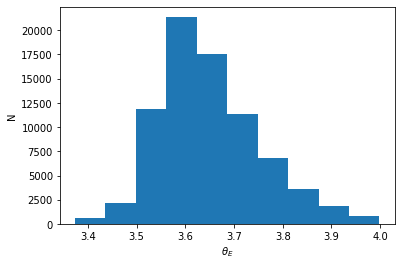

In [47]:
plt.hist(ds9_lenstronomy[0][1].T[0])
plt.xlabel('$θ_E$')
plt.ylabel('N');

In [48]:
# building a pandas dataframe and a fits file
ds9_lenstronomy_chain = pd.DataFrame(ds9_lenstronomy[0][1].T, ds9_lenstronomy[0][2])
ds9_lenstronomy_chain = ds9_lenstronomy_chain.T
# exporting chain results
ds9_lenstronomy_chain.to_csv('./output_dataframes/lenstronomy_013639_ds9.csv')

In [49]:
img_x, img_y

(array([-0.4392, -3.2544, -1.764 ,  2.2104]),
 array([ 3.448368, -1.951236, -3.08772 , -1.299456]))

In [50]:
kwargs_ds9_result

{'kwargs_lens': [{'theta_E': 3.6472414449289237,
   'e1': -0.07915531397815115,
   'e2': -0.05150700352365265,
   'center_x': 0.586129698160847,
   'center_y': 1.1842151985529528}],
 'kwargs_source': [],
 'kwargs_lens_light': [],
 'kwargs_ps': [{'ra_image': array([-0.43890182, -3.25644897, -1.76675819,  2.21129183]),
   'dec_image': array([ 3.44657452, -1.95029998, -3.08793317, -1.29936621]),
   'point_amp': array([1., 1., 1., 1.])}],
 'kwargs_special': {},
 'kwargs_extinction': []}

In [51]:
param_util.ellipticity2phi_q(kwargs_ds9_result['kwargs_lens'][0]['e1'], kwargs_ds9_result['kwargs_lens'][0]['e2'])

(-1.2823599061837923, 0.8274219341640955)

* bary point source analysis using Lenstronomy 

In [52]:
#_, noise_map_bary_al = gen_image_noise_pointsource(image_header, original_image, [list(a) for a in zip(ps_positions_x_bary, ps_positions_y_bary)], grid_scale)

In [53]:
# converting positions
img_x, img_y = rel_deg_to_arcsec(np.array(ps_positions_x_bary), np.array(ps_positions_y_bary), reference_position)
# ratios
flux_ratios = fluxes_bary[1:] / fluxes_bary[0]
# a little approximation here, error propagation over the ratio
flux_ratio_errors = [noise_map_bary[0]/fluxes_bary[1], noise_map_bary[0]/fluxes_bary[2], noise_map_bary[0]/fluxes_bary[3]]

In [54]:
# kwargs for a point-source fit

# we chose to model the image positions in the lensed plane (we know where they appear)
fixed_ps = [{}]  # neither image fixed
kwargs_ps_init = [{'ra_image': img_x, 'dec_image': img_y}] # the initial guess for the appearing image positions is: at the image position.
kwargs_ps_sigma = [{'ra_image': 0.01 * np.ones(len(img_x)), 'dec_image': 0.01 * np.ones(len(img_x))}]
kwargs_lower_ps = [{'ra_image': -10 * np.ones(len(img_x)), 'dec_image': -10 * np.ones(len(img_x))}]
kwargs_upper_ps = [{'ra_image': 10* np.ones(len(img_x)), 'dec_image': 10 * np.ones(len(img_x))}]

# combine all parameter options for lenstronomy
ps_params = [kwargs_ps_init, kwargs_ps_sigma, fixed_ps, kwargs_lower_ps, kwargs_upper_ps]

# kwargs over flux and source type
kwargs_flux_compute = {'source_type': 'INF',  # you can either chose 'INF' which is a infinetesimal source sice, 'GAUSSIAN' or 'TORUS'
                       'window_size': grid_scale, # window size to compute the finite source magnification (only when 'GAUSSIAN' or 'TORUS' are chosen.)
                       'grid_number': 150}

kwargs_data_joint = {'flux_ratios': flux_ratios, 
                     'flux_ratio_errors': flux_ratio_errors,
                    'ra_image_list': [img_x], 'dec_image_list': [img_y]}

# our model choices
kwargs_model = {'lens_model_list': lens_model, 
                'point_source_model_list': point_source_model
                 }
# neither important constraint to use
kwargs_constraints = {'num_point_source_list': [len(img_x)]              
                     }
# Likelihood kwargs
kwargs_likelihood = {'image_position_uncertainty': astrometry_sigma,  # astrometric uncertainty of image positions
                     'image_position_likelihood': True, # evaluate point source likelihood given the measured image positions
                     'flux_ratio_likelihood': flux_ratio_likelihood,  # enables the flux ratio likelihood 
                     'kwargs_flux_compute': kwargs_flux_compute,  # source_type='INF' will lead to point source
                     'check_bounds': True,  # check parameter bounds and punish them
                    }

kwargs_params = {'lens_model': lens_params,
                'point_source_model': ps_params}

In [55]:
#and now we run the MCMC
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params)

fitting_kwargs_list = [
    ['MCMC', {'n_burn': 400, 'n_run': 600, 'walkerRatio': 10,'sigma_scale': 0.1}]
]
bary_lenstronomy = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_bary_result = fitting_seq.best_fit()

2022-01-27 14:55:41,870 - lenstronomy.Sampling.Pool.pool - INFO - Running with SerialPool


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:29<00:00, 33.54it/s]

Computing the MCMC...
Number of walkers =  130
Burn-in iterations:  400
Sampling iterations (in current run): 1000
29.883188247680664 time taken for MCMC sampling


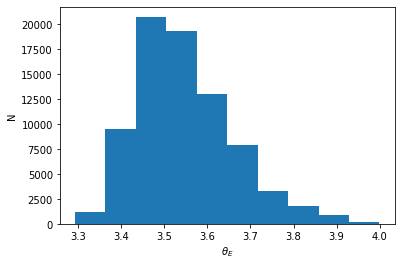

In [56]:
plt.hist(bary_lenstronomy[0][1].T[0])
plt.xlabel('$θ_E$')
plt.ylabel('N');

In [57]:
# building a pandas dataframe and a fits file
bary_lenstronomy_chain = pd.DataFrame(bary_lenstronomy[0][1].T, bary_lenstronomy[0][2])
bary_lenstronomy_chain = bary_lenstronomy_chain.T
# exporting chain results
bary_lenstronomy_chain.to_csv('./output_dataframes/lenstronomy_013639_bary.csv')

In [58]:
param_util.ellipticity2phi_q(kwargs_bary_result['kwargs_lens'][0]['e1'], kwargs_bary_result['kwargs_lens'][0]['e2'])

(0.1369224153176874, 0.9477874960726214)

* peak point source analysis using Lenstronomy 

In [59]:
#_, noise_map_peak = gen_image_noise_pointsource(image_header, original_image, [list(a) for a in zip(ps_positions_x_peak, ps_positions_y_peak)], grid_scale)

In [60]:
# converting positions
img_x, img_y = rel_deg_to_arcsec(np.array(ps_positions_x_peak), np.array(ps_positions_y_peak), reference_position)
# ratios
flux_ratios = fluxes_peak[1:] / fluxes_peak[0]
# a little approximation here, error propagation over the ratio
flux_ratio_errors = [noise_map_peak[0]/fluxes_peak[1], noise_map_peak[0]/fluxes_peak[2], noise_map_peak[0]/fluxes_peak[3]]

In [61]:
# kwargs for a point-source fit

# we chose to model the image positions in the lensed plane (we know where they appear)
fixed_ps = [{}]  # neither image fixed
kwargs_ps_init = [{'ra_image': img_x, 'dec_image': img_y}] # the initial guess for the appearing image positions is: at the image position.
kwargs_ps_sigma = [{'ra_image': 0.01 * np.ones(len(img_x)), 'dec_image': 0.01 * np.ones(len(img_x))}]
kwargs_lower_ps = [{'ra_image': -10 * np.ones(len(img_x)), 'dec_image': -10 * np.ones(len(img_x))}]
kwargs_upper_ps = [{'ra_image': 10* np.ones(len(img_x)), 'dec_image': 10 * np.ones(len(img_x))}]

# combine all parameter options for lenstronomy
ps_params = [kwargs_ps_init, kwargs_ps_sigma, fixed_ps, kwargs_lower_ps, kwargs_upper_ps]

# kwargs over flux and source type
kwargs_flux_compute = {'source_type': 'INF',  # you can either chose 'INF' which is a infinetesimal source sice, 'GAUSSIAN' or 'TORUS'
                       'window_size': grid_scale, # window size to compute the finite source magnification (only when 'GAUSSIAN' or 'TORUS' are chosen.)
                       'grid_number': 150}

kwargs_data_joint = {'flux_ratios': flux_ratios, 
                     'flux_ratio_errors': flux_ratio_errors,
                    'ra_image_list': [img_x], 'dec_image_list': [img_y]}

# our model choices
kwargs_model = {'lens_model_list': lens_model, 
                'point_source_model_list': point_source_model
                 }
# neither important constraint to use
kwargs_constraints = {'num_point_source_list': [len(img_x)]              
                     }
# Likelihood kwargs
kwargs_likelihood = {'image_position_uncertainty': astrometry_sigma,  # astrometric uncertainty of image positions
                     'image_position_likelihood': True, # evaluate point source likelihood given the measured image positions
                     'flux_ratio_likelihood': flux_ratio_likelihood,  # enables the flux ratio likelihood 
                     'kwargs_flux_compute': kwargs_flux_compute,  # source_type='INF' will lead to point source
                     'check_bounds': True,  # check parameter bounds and punish them
                    }

kwargs_params = {'lens_model': lens_params,
                'point_source_model': ps_params}

In [62]:
#and now we run the MCMC
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, kwargs_params)

fitting_kwargs_list = [
    ['MCMC', {'n_burn': 400, 'n_run': 600, 'walkerRatio': 10,'sigma_scale': 0.1}]
]
peak_lenstronomy = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_peak_result = fitting_seq.best_fit()

2022-01-27 14:56:13,254 - lenstronomy.Sampling.Pool.pool - INFO - Running with SerialPool


100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:30<00:00, 32.99it/s]

Computing the MCMC...
Number of walkers =  130
Burn-in iterations:  400
Sampling iterations (in current run): 1000
30.378532886505127 time taken for MCMC sampling


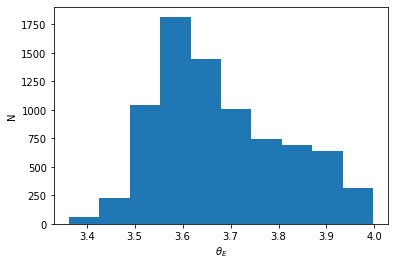

In [63]:
plt.hist(peak_lenstronomy[0][1].T[0][70000:])
plt.xlabel('$θ_E$')
plt.ylabel('N');

In [64]:
# building a pandas dataframe and a fits file
peak_lenstronomy_chain = pd.DataFrame(peak_lenstronomy[0][1].T, peak_lenstronomy[0][2])
peak_lenstronomy_chain = peak_lenstronomy_chain.T
# exporting chain results
peak_lenstronomy_chain.to_csv('./output_dataframes/lenstronomy_013639_peak.csv')

In [65]:
kwargs_peak_result

{'kwargs_lens': [{'theta_E': 3.496945620600235,
   'e1': -0.014058778932717578,
   'e2': 0.01796064962202283,
   'center_x': 0.13685199388905744,
   'center_y': 0.7156819129509935}],
 'kwargs_source': [],
 'kwargs_lens_light': [],
 'kwargs_ps': [{'ra_image': array([-0.32538722, -3.30163638, -1.62796886,  2.27760329]),
   'dec_image': array([ 3.42094485, -1.78808359, -3.0891438 , -1.22995077]),
   'point_amp': array([1., 1., 1., 1.])}],
 'kwargs_special': {},
 'kwargs_extinction': []}

In [66]:
img_x, img_y

(array([-0.3276, -3.3012, -1.6272,  2.2788]),
 array([ 3.422664, -1.786536, -3.089736, -1.228536]))

In [67]:
param_util.ellipticity2phi_q(kwargs_peak_result['kwargs_lens'][0]['e1'], kwargs_peak_result['kwargs_lens'][0]['e2'])

(1.1174664463330806, 0.9553999797500948)